In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.optimize import curve_fit

In [15]:
df_1_7 = pd.read_csv("output/default.csv")
df_0_5 = pd.read_csv("output/BField_0_5T.csv")
df_1_0 = pd.read_csv("output/BField_1_0T.csv")
# df_2_5 = pd.read_csv("output/BField_2_5T.csv")

In [4]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

In [16]:
df_1_7.head()

,True Momentum (MeV/c),True Transverse Momentum (MeV/c),True Z Momentum (MeV/c),Fitted Momentum (MeV/c),Fitted Transverse Momentum (MeV/c),Fitted Z Momentum (MeV/c),Pseudorapidity,DCA (mm),Number of Hits
0,500,451.744107,214.306467,498.586059,449.944452,-214.797694,0.458196,0.019325,5
1,500,454.441433,208.525740,498.643029,453.715328,-206.850843,0.444117,0.003964,5
2,700,469.321697,519.362248,699.144523,467.719803,-519.654934,0.954795,0.112657,4
3,5000,4701.210612,-1702.533050,5005.676703,4706.959101,1703.330642,-0.354665,0.010375,5
4,500,431.350178,252.857714,499.816765,430.641319,-253.702291,0.556956,0.099995,5


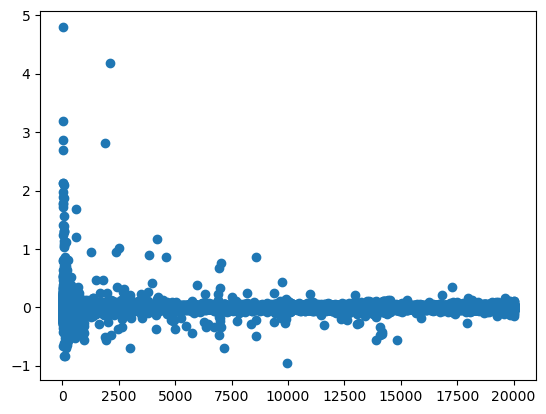

In [17]:
pT_residual = (df_1_7["Fitted Transverse Momentum (MeV/c)"] - df_1_7["True Transverse Momentum (MeV/c)"]) / df_1_7["True Transverse Momentum (MeV/c)"]
plt.scatter(df_1_7["True Transverse Momentum (MeV/c)"], pT_residual)

In [35]:
for i in sorted(df_1_7["Number of Hits"].unique()):
    print(i, len(df_1_7[df_1_7["Number of Hits"] == i].index))

4 80715
5 341247
6 30390
7 14335
8 6525
9 1400
10 1056
11 285
12 379
13 269
14 272
15 287
16 218
17 157
18 128
19 135
20 144
21 91
22 67
23 63
24 66
25 70
26 53
27 59
28 76
29 46
30 33
31 31
32 34
33 26
34 34
35 42
36 41
37 25
38 16
39 20
40 16
41 26
42 13
43 23
44 28
45 11
46 12
47 11
48 13
49 14
50 14
51 16
52 19
53 12
54 6
55 11
56 6
57 6
58 4
59 12
60 7
61 7
62 2
63 2
64 4
65 9
66 6
67 5
68 6
69 2
70 6
71 2
72 2
73 4
74 4
75 2
76 2
77 4
78 3
79 3
80 2
81 4
82 1
83 1
84 1
86 1
87 1


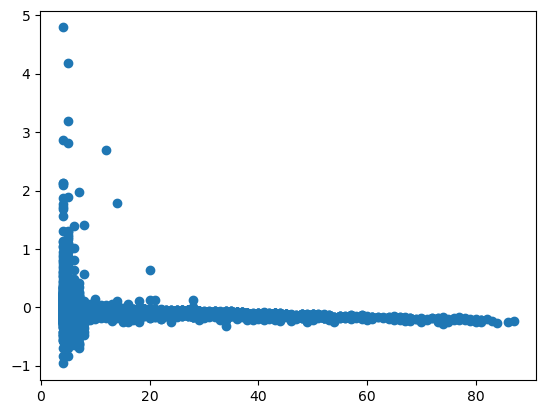

In [19]:
plt.scatter(df_1_7["Number of Hits"], pT_residual)

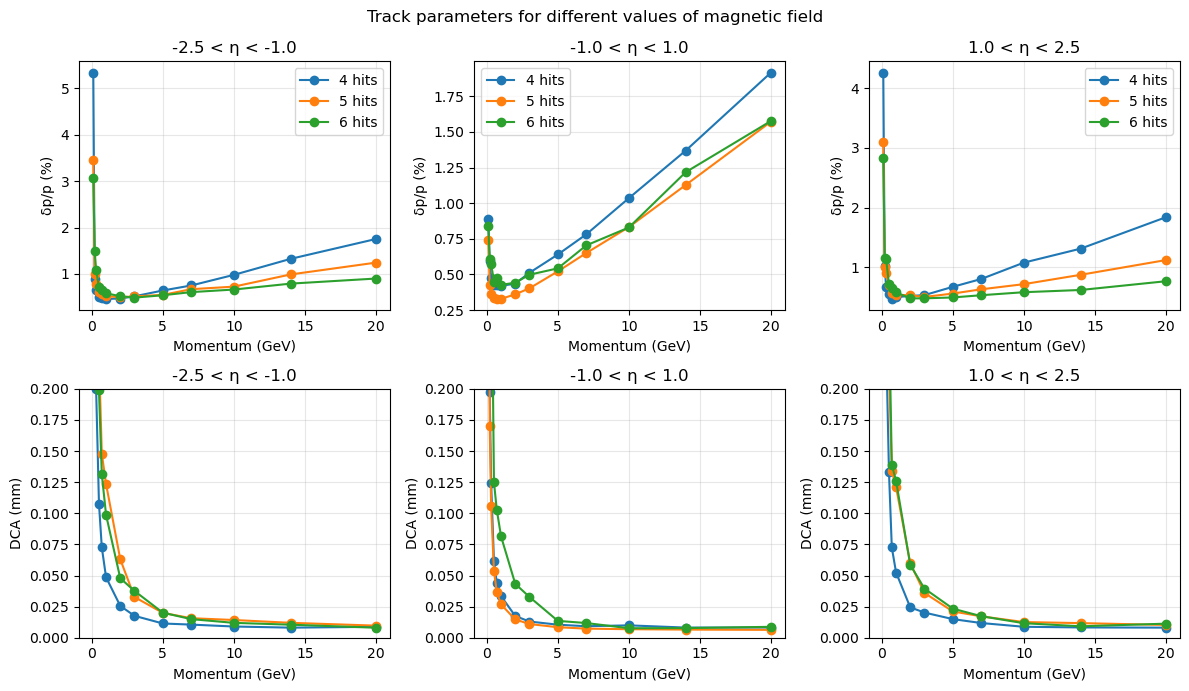

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for numHits in range(4, 7):
    df = df_1_7[df_1_7["Number of Hits"] == numHits]
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            if (len(subset.index) < 10):
                print(numHits, p, len(subset.index))
                continue
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o", label=f"{numHits} hits")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, marker="o", label=f"{numHits} hits")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()

plt.suptitle("Track parameters for different values of magnetic field")
plt.tight_layout()
plt.show()

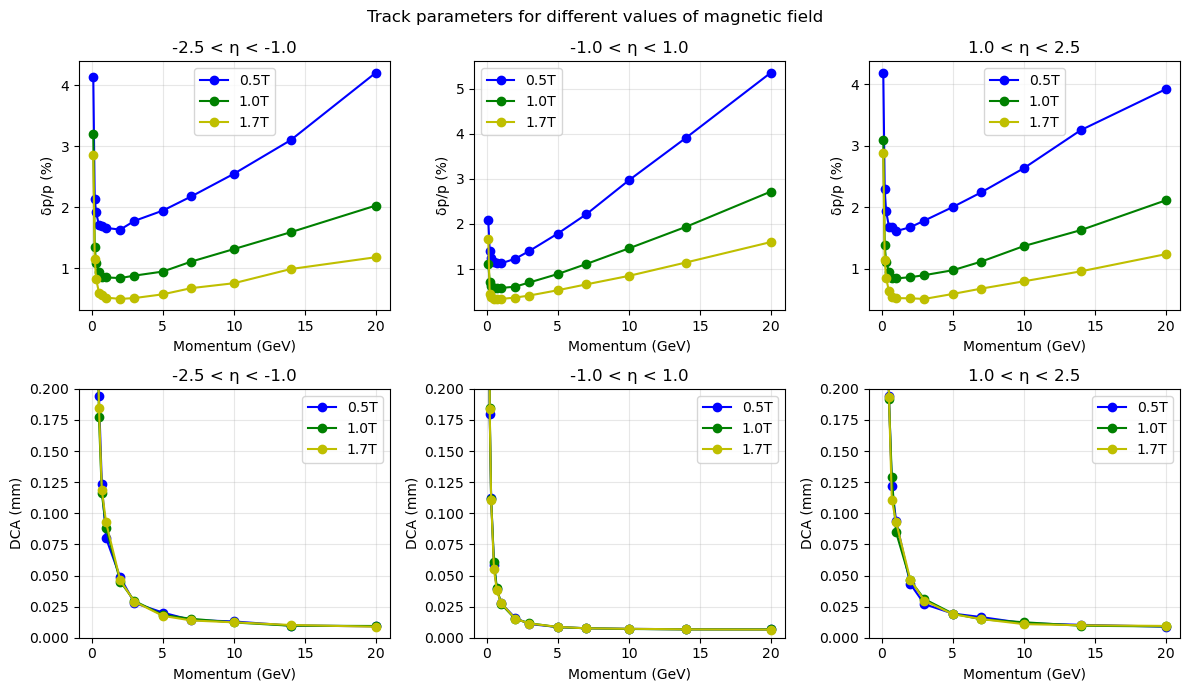

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {0.5: df_0_5, 1.0: df_1_0, 1.7: df_1_7}
colors = {0.5: "b", 1.0: "g", 1.7: "y"}

for B, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[B], marker="o", label=f"{B}T")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[B], marker="o", label=f"{B}T")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()

plt.suptitle("Track parameters for different values of magnetic field")
plt.tight_layout()
plt.show()

In [ ]:
df_7um = pd.read_csv("output/default.csv")
df_4um = pd.read_csv("output/resolution_4um.csv")
df_10um = pd.read_csv("output/resolution_10um.csv")
df_13um = pd.read_csv("output/resolution_13um.csv")

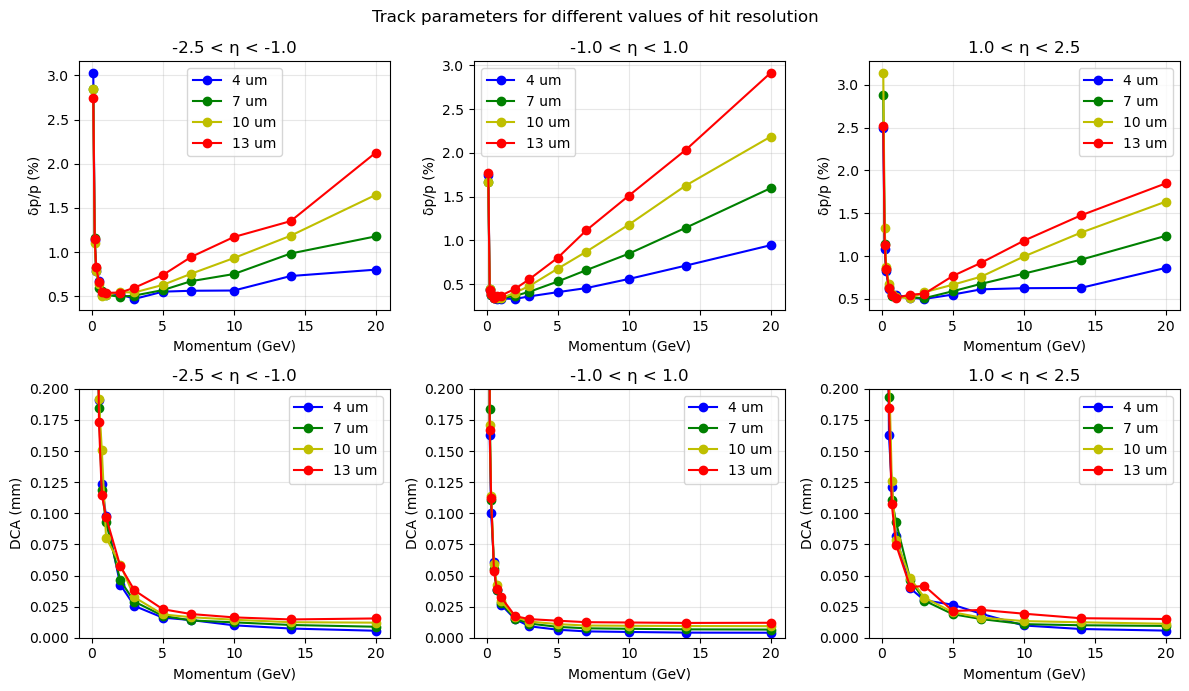

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {4: df_4um, 7: df_7um, 10: df_10um, 13: df_13um}
colors = {4: "b", 7: "g", 10: "y", 13: "r"}

for res, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[res], marker="o", label=f"{res} um")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[res], marker="o", label=f"{res} um")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different values of hit resolution")
plt.tight_layout()
plt.show()

In [ ]:
df_25um = pd.read_csv("output/width_25um.csv")
df_50um = pd.read_csv("output/default.csv")
df_75um = pd.read_csv("output/width_75um.csv")
df_100um = pd.read_csv("output/width_100um.csv")

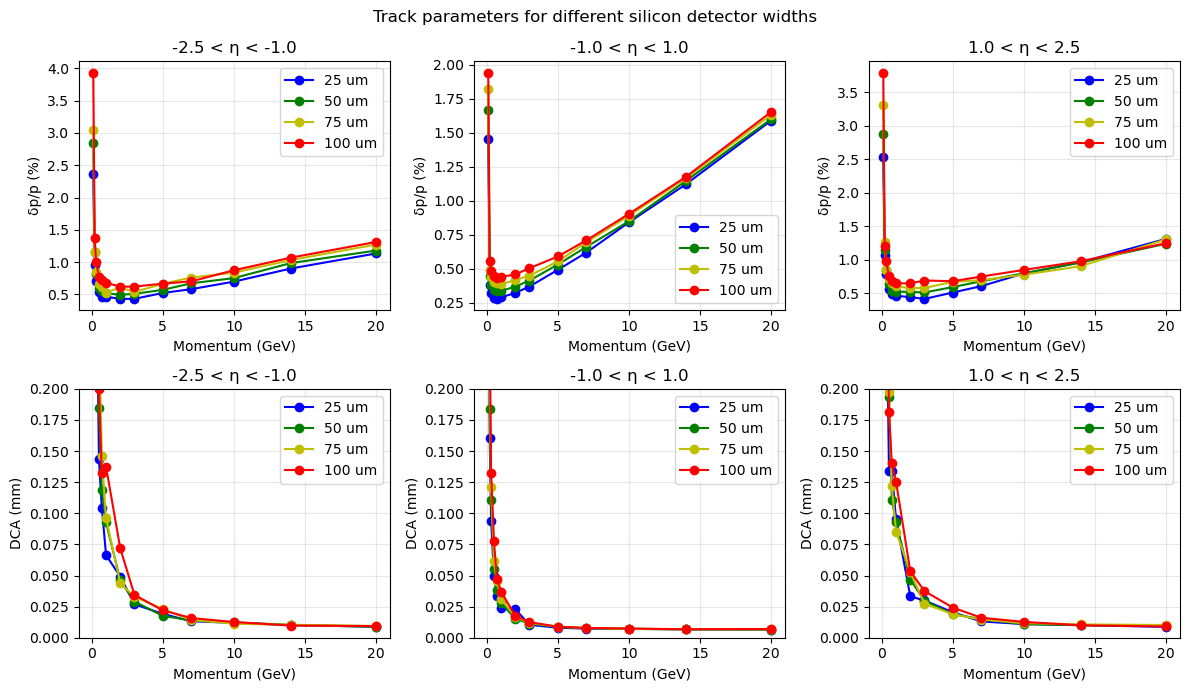

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {25: df_25um, 50: df_50um, 75: df_75um, 100: df_100um}
colors = {25: "b", 50: "g", 75: "y", 100: "r"}

for width, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[width], marker="o", label=f"{width} um")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[width], marker="o", label=f"{width} um")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different silicon detector widths")
plt.tight_layout()
plt.show()